# Fake vs Real News Headline Classifier

**Task:** Binary classification of news headlines as **fake** (`0`) or **real** (`1`).

**Approach:** We compare three models of increasing complexity:

| # | Model | Strategy |
|---|---|---|
| 1 | TF-IDF + Logistic Regression | Sparse bag-of-words baseline |
| 2 | Sentence Transformers + LR | Frozen dense embeddings (`all-MiniLM-L6-v2`) |
| 3 | DistilBERT fine-tuned | End-to-end transformer fine-tuning |

In [48]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                     StratifiedKFold, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve,
                             f1_score, precision_score, recall_score)

sns.set_style('whitegrid')

## 1. Load & Explore Data

In [49]:
# Google Colab mount (comment out if running locally)
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/NLP/dataset'

# Local alternative (uncomment if running outside Colab):
# DATA_DIR = 'dataset'

train = pd.read_csv(f'{DATA_DIR}/training_data.csv', sep='\t', header=None,
                    names=['label', 'headline'], encoding='utf-8-sig')
test  = pd.read_csv(f'{DATA_DIR}/testing_data.csv',  sep='\t', header=None,
                    names=['label', 'headline'], encoding='utf-8-sig')

# Strip BOM artefacts from labels and cast to int
train['label'] = train['label'].astype(str).str.replace('\ufeff', '', regex=False).astype(int)

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f"\nLabel distribution (train):\n{train['label'].value_counts()}")
train.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (34152, 2)  |  Test: (9984, 2)

Label distribution (train):
label
0    17572
1    16580
Name: count, dtype: int64


,label,headline
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...


## 2. Text Cleaning

In [50]:
def clean(text):
    """Lowercase, remove non-alpha characters, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean'] = train['headline'].apply(clean)
test['clean']  = test['headline'].apply(clean)

train[['headline', 'clean']].head(3)

,headline,clean
0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year s...
1,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...


---
## Part I — TF-IDF + Logistic Regression (Baseline)

A fast, interpretable baseline: TF-IDF converts headlines into sparse weighted
term-frequency vectors, then Logistic Regression draws a linear decision boundary.

### 3. Build Pipeline

In [51]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),   # unigrams + bigrams
        max_features=50_000,
        sublinear_tf=True,    # 1 + log(TF) dampens frequent terms
        stop_words='english'
    )),
    ('clf', LogisticRegression(
        C=5.0,
        max_iter=1000,
        solver='lbfgs',
        n_jobs=-1
    ))
])

### 4. Cross-Validation

In [52]:
X_clean = train['clean']
y       = train['label']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_tfidf = cross_val_score(pipe, X_clean, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'CV Accuracy: {scores_tfidf.mean():.4f} \u00b1 {scores_tfidf.std():.4f}')
print(f'Per-fold:    {np.round(scores_tfidf, 4)}')

CV Accuracy: 0.9416 ± 0.0033
Per-fold:    [0.9426 0.9444 0.9382 0.9372 0.9454]


### 5. OOF Evaluation

              precision    recall  f1-score   support

        fake       0.95      0.94      0.94     17572
        real       0.93      0.95      0.94     16580

    accuracy                           0.94     34152
   macro avg       0.94      0.94      0.94     34152
weighted avg       0.94      0.94      0.94     34152

ROC-AUC: 0.9855


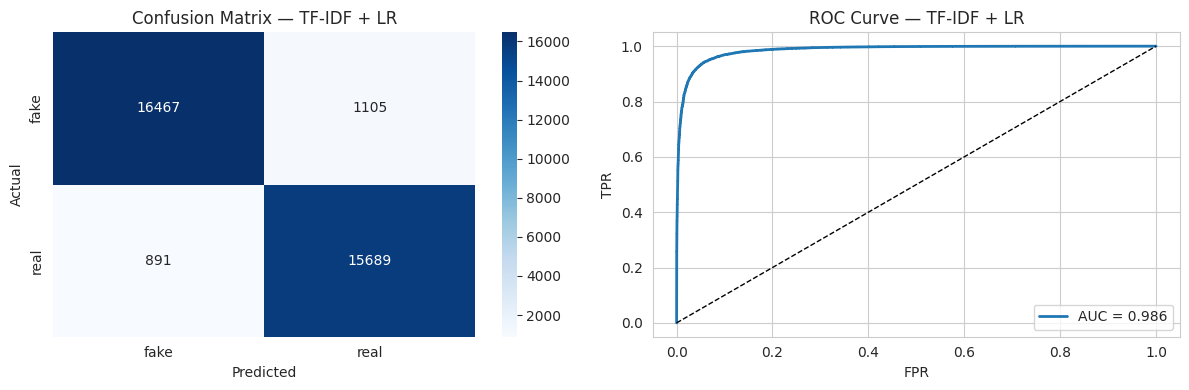

In [53]:
# Out-of-fold predictions: each sample scored by the fold that held it out
oof_preds = cross_val_predict(pipe, X_clean, y, cv=cv, n_jobs=-1)
oof_proba = cross_val_predict(pipe, X_clean, y, cv=cv,
                              method='predict_proba', n_jobs=-1)[:, 1]

print(classification_report(y, oof_preds, target_names=['fake', 'real']))

auc_tfidf = roc_auc_score(y, oof_proba)
print(f'ROC-AUC: {auc_tfidf:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y, oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['fake', 'real'], yticklabels=['fake', 'real'])
axes[0].set_title('Confusion Matrix \u2014 TF-IDF + LR')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y, oof_proba)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_tfidf:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve \u2014 TF-IDF + LR')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6. Train on Full Set & Predict

In [54]:
pipe.fit(X_clean, y)

test_preds_tfidf = pipe.predict(test['clean'])

output_tfidf = test[['headline']].copy()
output_tfidf.insert(0, 'label', test_preds_tfidf)
output_tfidf.to_csv(f'{DATA_DIR}/predictions.csv', sep='\t',
                    header=False, index=False, encoding='utf-8-sig')

print('Saved: predictions.csv')
print(f"Predicted distribution:\n{pd.Series(test_preds_tfidf).value_counts()}")

Saved: predictions.csv
Predicted distribution:
1    5239
0    4745
Name: count, dtype: int64


### 7. Sample Predictions

In [55]:
output_tfidf.head(10)

,label,headline
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,0,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...
5,0,did oprah just leave ‚nasty‚ hillary wishing s...
6,1,france's macron says his job not 'cool' cites ...
7,0,flashback: chilling ‚60 minutes‚ interview wit...
8,1,spanish foreign ministry says to expel north k...
9,1,trump says cuba 'did some bad things' aimed at...


---
## Part II — Sentence Transformers + Logistic Regression

Instead of bag-of-words, we encode each headline into a **384-dimensional dense vector**
using a pre-trained sentence embedding model (`all-MiniLM-L6-v2`), then classify
with Logistic Regression. The embeddings capture semantic similarity that TF-IDF misses.

### 8. Encode Headlines

In [56]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('all-MiniLM-L6-v2')

# 80/20 stratified split for validation
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train['headline'], y, test_size=0.2, random_state=42, stratify=y
)

print('Encoding train / val / test sets...')
X_train_emb = st_model.encode(X_train_text.tolist(), batch_size=256, show_progress_bar=True)
X_val_emb   = st_model.encode(X_val_text.tolist(),   batch_size=256, show_progress_bar=True)
X_test_emb  = st_model.encode(test['headline'].tolist(), batch_size=256, show_progress_bar=True)

print(f'Embedding shape: {X_train_emb.shape}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train / val / test sets...


Batches:   0%|          | 0/107 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/39 [00:00<?, ?it/s]

Embedding shape: (27321, 384)


### 9. Cross-Validation on Full Embeddings

In [57]:
# Encode the full training set for CV (separate from the 80/20 val split)
X_full_emb = st_model.encode(train['headline'].tolist(), batch_size=256, show_progress_bar=True)

lr_cv = LogisticRegression(C=5.0, max_iter=1000, n_jobs=-1)
scores_st = cross_val_score(lr_cv, X_full_emb, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'CV Accuracy: {scores_st.mean():.4f} \u00b1 {scores_st.std():.4f}')
print(f'Per-fold:    {np.round(scores_st, 4)}')

Batches:   0%|          | 0/134 [00:00<?, ?it/s]

CV Accuracy: 0.9305 ± 0.0019
Per-fold:    [0.9328 0.9308 0.9318 0.9274 0.9299]


### 10. Train, Validate & Predict

In [58]:
lr_emb = LogisticRegression(C=5.0, max_iter=1000, random_state=42, n_jobs=-1)
lr_emb.fit(X_train_emb, y_train)

preds_val = lr_emb.predict(X_val_emb)
print(classification_report(y_val, preds_val, target_names=['fake', 'real']))

# Retrain on full training set, then predict test
lr_emb.fit(X_full_emb, y)
preds_st = lr_emb.predict(X_test_emb)

output_st = test[['headline']].copy()
output_st.insert(0, 'label', preds_st)
output_st.to_csv(f'{DATA_DIR}/predictions_sentence_transformers.csv', sep='\t',
                 header=False, index=False, encoding='utf-8-sig')

print('Saved: predictions_sentence_transformers.csv')
print(f"Predicted distribution:\n{pd.Series(preds_st).value_counts()}")

              precision    recall  f1-score   support

        fake       0.94      0.92      0.93      3515
        real       0.91      0.94      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831

Saved: predictions_sentence_transformers.csv
Predicted distribution:
1    5267
0    4717
Name: count, dtype: int64


### 11. Detailed Metrics

ROC-AUC (val): 0.9830


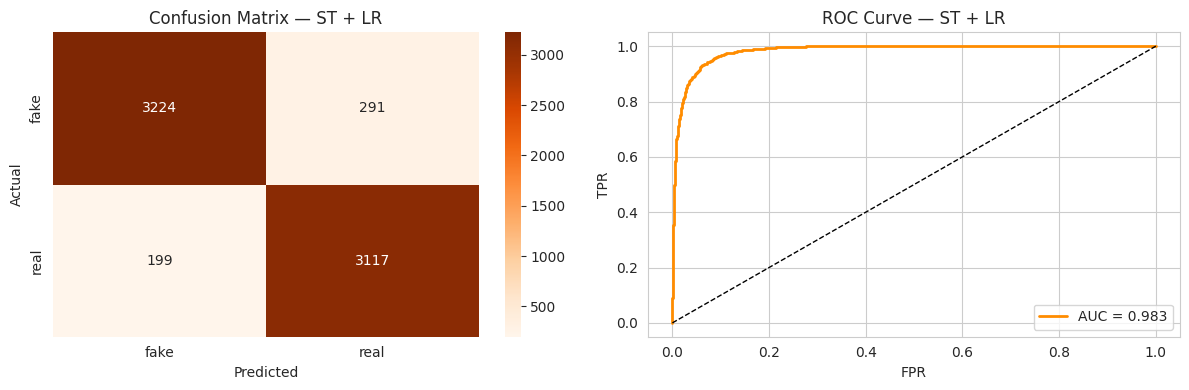

In [59]:
proba_val_st = lr_emb.predict_proba(X_val_emb)[:, 1]
auc_st = roc_auc_score(y_val, proba_val_st)
print(f'ROC-AUC (val): {auc_st:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_st = confusion_matrix(y_val, preds_val)
sns.heatmap(cm_st, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['fake', 'real'], yticklabels=['fake', 'real'])
axes[0].set_title('Confusion Matrix \u2014 ST + LR')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr_st, tpr_st, _ = roc_curve(y_val, proba_val_st)
axes[1].plot(fpr_st, tpr_st, lw=2, color='darkorange', label=f'AUC = {auc_st:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve \u2014 ST + LR')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Part III — DistilBERT Fine-Tuning

End-to-end fine-tuning of `distilbert-base-uncased`. Unlike the previous models,
BERT's subword tokenizer and contextual attention layers are updated during training,
allowing the model to learn task-specific representations.

> GPU recommended (~5 min on GPU, ~30 min on CPU).  
> Install: `pip install transformers datasets accelerate`

### 12. Tokenize & Prepare Datasets

In [60]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset
import torch

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['headline'], truncation=True, padding='max_length', max_length=64)

# Reuse the same 80/20 split from Part II so all models are evaluated on identical data
train_hf = Dataset.from_dict({'headline': X_train_text.tolist(), 'label': y_train.tolist()})
val_hf   = Dataset.from_dict({'headline': X_val_text.tolist(),   'label': y_val.tolist()})
test_hf  = Dataset.from_dict({'headline': test['headline'].tolist(),
                               'label': [0] * len(test)})  # placeholder labels

train_hf = train_hf.map(tokenize, batched=True, batch_size=512)
val_hf   = val_hf.map(tokenize,   batched=True, batch_size=512)
test_hf  = test_hf.map(tokenize,  batched=True, batch_size=512)

for ds in [train_hf, val_hf, test_hf]:
    ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f'Train: {len(train_hf)}  |  Val: {len(val_hf)}  |  Test: {len(test_hf)}')

Map:   0%|          | 0/27321 [00:00<?, ? examples/s]

Map:   0%|          | 0/6831 [00:00<?, ? examples/s]

Map:   0%|          | 0/9984 [00:00<?, ? examples/s]

Train: 27321  |  Val: 6831  |  Test: 9984


### 13. Fine-Tune

In [61]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds)}

bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir='./bert_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy='epoch',
    save_strategy='no',
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.084304,0.058937,0.978773
2,0.041370,0.056083,0.983897
3,0.021555,0.052712,0.985654


TrainOutput(global_step=2562, training_loss=0.07923683461316576, metrics={'train_runtime': 167.165, 'train_samples_per_second': 490.312, 'train_steps_per_second': 15.326, 'total_flos': 1357178174505216.0, 'train_loss': 0.07923683461316576, 'epoch': 3.0})

### 14. Evaluate on Validation Set & Predict Test

              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3515
        real       0.99      0.98      0.99      3316

    accuracy                           0.99      6831
   macro avg       0.99      0.99      0.99      6831
weighted avg       0.99      0.99      0.99      6831

ROC-AUC (val): 0.9990


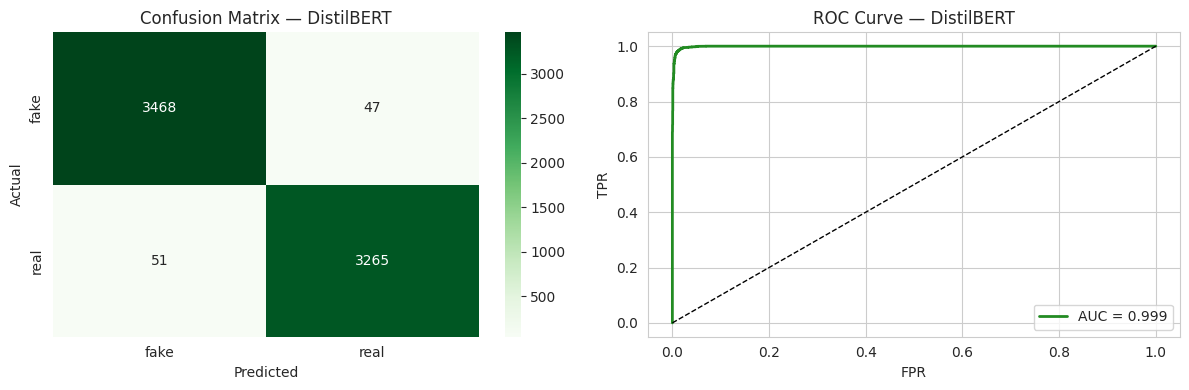


Saved: predictions_distilbert.csv
Predicted distribution:
0    5022
1    4962
Name: count, dtype: int64


In [62]:
# Evaluate on the same 20% val split used by ST
val_output = trainer.predict(val_hf)
preds_val_bert  = np.argmax(val_output.predictions, axis=-1)
proba_val_bert  = torch.softmax(torch.tensor(val_output.predictions), dim=-1)[:, 1].numpy()

print(classification_report(y_val, preds_val_bert, target_names=['fake', 'real']))

auc_bert = roc_auc_score(y_val, proba_val_bert)
print(f'ROC-AUC (val): {auc_bert:.4f}')

# Confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_bert = confusion_matrix(y_val, preds_val_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['fake', 'real'], yticklabels=['fake', 'real'])
axes[0].set_title('Confusion Matrix \u2014 DistilBERT')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr_bert, tpr_bert, _ = roc_curve(y_val, proba_val_bert)
axes[1].plot(fpr_bert, tpr_bert, lw=2, color='forestgreen', label=f'AUC = {auc_bert:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve \u2014 DistilBERT')
axes[1].legend()

plt.tight_layout()
plt.show()

# Predict on unlabeled test set and save
bert_test_raw = trainer.predict(test_hf)
preds_bert = np.argmax(bert_test_raw.predictions, axis=-1)

output_bert = test[['headline']].copy()
output_bert.insert(0, 'label', preds_bert)
output_bert.to_csv(f'{DATA_DIR}/predictions_distilbert.csv', sep='\t',
                   header=False, index=False, encoding='utf-8-sig')

print(f'\nSaved: predictions_distilbert.csv')
print(f"Predicted distribution:\n{pd.Series(preds_bert).value_counts()}")

---
## Model Comparison

Side-by-side evaluation of all three models on key classification metrics.  
TF-IDF uses out-of-fold scores; Sentence Transformers and DistilBERT use the same 20% validation split.

             Accuracy  Precision  Recall      F1  ROC-AUC
TF-IDF + LR    0.9416     0.9342  0.9463  0.9402   0.9855
ST + LR        0.9283     0.9146  0.9400  0.9271   0.9830
DistilBERT     0.9857     0.9858  0.9846  0.9852   0.9990


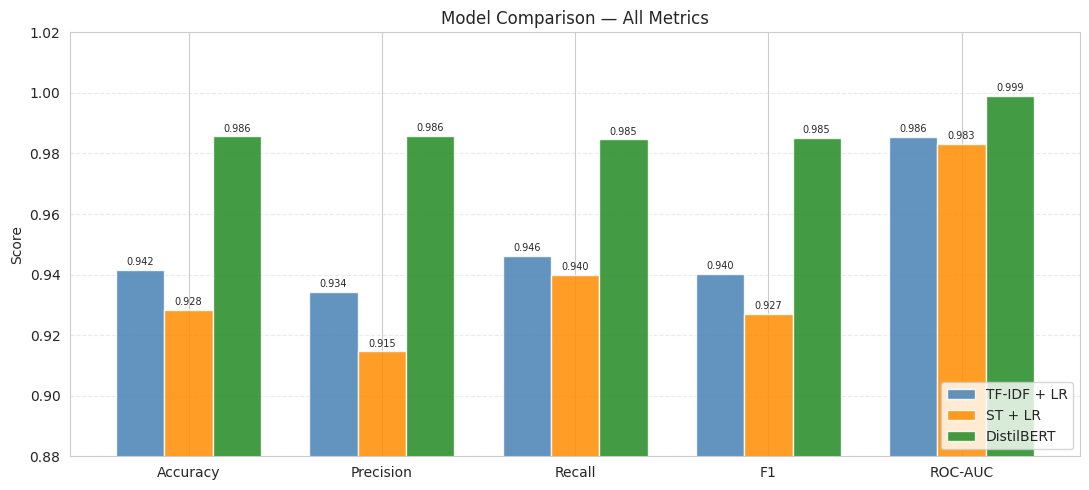

In [63]:
# ── Collect metrics ──
tfidf_m = {
    'Accuracy':  scores_tfidf.mean(),
    'Precision': precision_score(y, oof_preds),
    'Recall':    recall_score(y, oof_preds),
    'F1':        f1_score(y, oof_preds),
    'ROC-AUC':   auc_tfidf,
}

st_m = {
    'Accuracy':  accuracy_score(y_val, preds_val),
    'Precision': precision_score(y_val, preds_val),
    'Recall':    recall_score(y_val, preds_val),
    'F1':        f1_score(y_val, preds_val),
    'ROC-AUC':   auc_st,
}

bert_m = {
    'Accuracy':  accuracy_score(y_val, preds_val_bert),
    'Precision': precision_score(y_val, preds_val_bert),
    'Recall':    recall_score(y_val, preds_val_bert),
    'F1':        f1_score(y_val, preds_val_bert),
    'ROC-AUC':   auc_bert,
}

model_names  = ['TF-IDF + LR', 'ST + LR', 'DistilBERT']
metric_names = list(tfidf_m.keys())
vals         = [list(tfidf_m.values()), list(st_m.values()), list(bert_m.values())]

# ── Table ──
df_comp = pd.DataFrame({'TF-IDF + LR': tfidf_m, 'ST + LR': st_m, 'DistilBERT': bert_m}).T
df_comp.columns = metric_names
print(df_comp.round(4).to_string())

# ── Bar chart ──
x = np.arange(len(metric_names))
width = 0.25
colors = ['steelblue', 'darkorange', 'forestgreen']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, v, c) in enumerate(zip(model_names, vals, colors)):
    bars = ax.bar(x + i * width, v, width, label=name, color=c, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.88, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()